In [1]:
import tensorflow as tf
tf.__version__

'1.1.0'

In [2]:
from glob import glob

In [3]:
import cv2

from numpy.random import seed
seed(123)
from tensorflow import set_random_seed
set_random_seed(123)

import numpy as np
import os

import matplotlib.pyplot as plt
%matplotlib inline

from scipy import stats

In [4]:
from keras.models import Model, load_model
from keras.layers import Input
from keras.layers.core import Lambda, RepeatVector, Reshape
from keras.layers.convolutional import Conv2D, Conv2DTranspose
from keras.layers.pooling import MaxPooling2D
from keras.layers.merge import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras import backend as K

Using TensorFlow backend.


In [5]:
# Build U-Net model

# height = 720
# width = 1280

height = 624
width = 1160

input_img = Input((height, width, 3), name='img')

c1 = Conv2D(8, (3, 3), activation='relu', padding='same') (input_img)
c1 = Conv2D(8, (3, 3), activation='relu', padding='same') (c1)
p1 = MaxPooling2D((2, 2)) (c1)

c2 = Conv2D(16, (3, 3), activation='relu', padding='same') (p1)
c2 = Conv2D(16, (3, 3), activation='relu', padding='same') (c2)
p2 = MaxPooling2D((2, 2)) (c2)

c3 = Conv2D(32, (3, 3), activation='relu', padding='same') (p2)
c3 = Conv2D(32, (3, 3), activation='relu', padding='same') (c3)
p3 = MaxPooling2D((2, 2)) (c3)

c4 = Conv2D(64, (3, 3), activation='relu', padding='same') (p3)
c4 = Conv2D(64, (3, 3), activation='relu', padding='same') (c4)

u5 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same') (c4)
u5 = concatenate([u5, c3])
c6 = Conv2D(32, (3, 3), activation='relu', padding='same') (u5)
c6 = Conv2D(32, (3, 3), activation='relu', padding='same') (c6)

u7 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same') (c6)
u7 = concatenate([u7, c2])
c7 = Conv2D(16, (3, 3), activation='relu', padding='same') (u7)
c7 = Conv2D(16, (3, 3), activation='relu', padding='same') (c7)

u8 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same') (c7)
u8 = concatenate([u8, c1])
c8 = Conv2D(8, (3, 3), activation='relu', padding='same') (u8)
c8 = Conv2D(8, (3, 3), activation='relu', padding='same') (c8)

outputs = Conv2D(1, (1, 1), activation='sigmoid') (c8)

model = Model(inputs=[input_img], outputs=[outputs])
model.compile(optimizer='adam', loss='binary_crossentropy') #, metrics=[mean_iou]) # The mean_iou metrics seens to leak train and test values...
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                (None, 624, 1160, 3) 0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 624, 1160, 8) 224         img[0][0]                        
__________________________________________________________________________________________________
conv2d_2 (Conv2D)               (None, 624, 1160, 8) 584         conv2d_1[0][0]                   
__________________________________________________________________________________________________
max_pooling2d_1 (MaxPooling2D)  (None, 312, 580, 8)  0           conv2d_2[0][0]                   
__________________________________________________________________________________________________
conv2d_3 (

In [6]:
model.load_weights('final-road-seg-model-v2.h5')

In [37]:
test_image = cv2.imread('orchard_images/bag1/frame249.png')

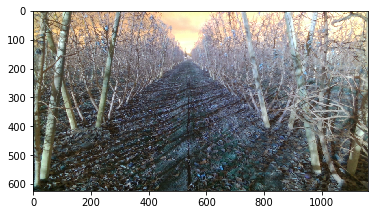

In [38]:
plt.imshow(cv2.resize(test_image, (width, height)))

In [39]:
test_image = cv2.resize(test_image, (width, height))

In [40]:
my_preds = model.predict(np.expand_dims(test_image, 0))

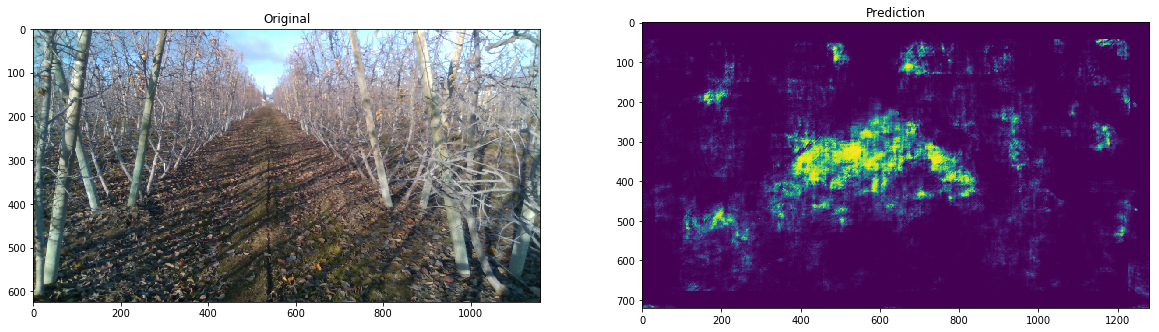

In [41]:
fig, ax = plt.subplots(figsize=(20,18),nrows=1, ncols=2)
ax[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original')

preds_resized = cv2.resize( my_preds.reshape(height,width), ( 1280, 720))

ax[1].imshow( preds_resized)
ax[1].set_title('Prediction')
# plt.show()
# plt.savefig("roadSegmentationPrediction.png", bbox_inches='tight')

In [54]:
import scipy

In [55]:
scipy.misc.imsave("roadSegmentationPrediction.png", preds_resized)

/home/abhijay/anaconda3/envs/tf_v1/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: `imsave` is deprecated!
`imsave` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imwrite`` instead.
  """Entry point for launching an IPython kernel.


In [36]:
# img = cv2.imread('failed_roadsegmentation_.png')

# img = cv2.resize(img, (1280, 720))

# plt.imshow(img)

# cv2.imwrite("imagesForThePaper/failed_roadsegmentation.png", img)

Text(0.5,1,'Original')

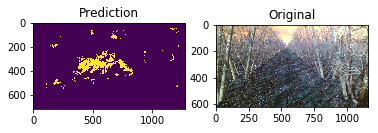

In [42]:
my_preds = preds_resized.flatten()
my_preds = np.array([1 if i >= 0.5 else 0 for i in my_preds])
fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(my_preds.reshape(720, 1280))
ax[0].set_title('Prediction')
ax[1].imshow(test_image)
ax[1].set_title('Original')

In [43]:
points = np.nonzero(my_preds.reshape(720, 1280))[1]
z = np.abs(stats.zscore(points))
points = np.unique(points[np.where(z > 0.8)])
preds = my_preds.reshape(720,1280)
preds[:,points] = np.zeros((720,len(points)))
mid = int(np.mean(np.unique(np.nonzero(preds)[1])))

True

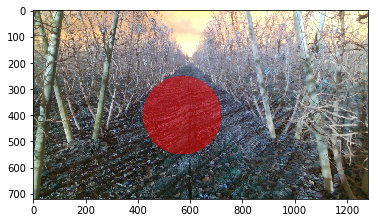

In [44]:
alpha = 0.5

img = cv2.imread('orchard_images/bag1/frame250.png')
overlay = img.copy()
output = img.copy()


waypoint = cv2.circle(overlay, (int(mid),400), 150, (255,0,0), -1)
# waypoint = cv2.circle(overlay, (int(depthPathMid),400), 150, (0,255,0), -1)
waypoint = cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)

plt.imshow(output)

cv2.imwrite('roadSegmentationSample.png', output)

In [7]:
# img_folders = ['bag1','bag2']
img_folders = ['bag3','bag4']

In [15]:
for img_folder in img_folders:
    prediction_file = open('roadSegmentation_predictions/'+img_folder+'/predictions.csv','w')
    
    filenames = glob('orchard_images/'+img_folder+'/frame*')
    for filename in filenames:

        test_image = cv2.imread(filename)

        test_image = cv2.resize(test_image, (width, height))
        my_preds = model.predict(np.expand_dims(test_image, 0))
        
        preds_resized = cv2.resize( my_preds.reshape(height,width), ( 1280, 720))
        my_preds = preds_resized.flatten()
        
        my_preds = my_preds.flatten()
        my_preds = np.array([1 if i >= 0.5 else 0 for i in my_preds])
        
        points = np.nonzero(my_preds.reshape(720, 1280))[1]
        z = np.abs(stats.zscore(points))
        points = np.unique(points[np.where(z > 0.8)])
        preds = my_preds.reshape(720,1280)
        preds[:,points] = np.zeros((720,len(points)))
        
        if np.nonzero(preds)[1].size!=0:
            mid = int(np.mean(np.unique(np.nonzero(preds)[1])))
        else:
            mid = 0

        prediction_file.write(filename.split('.')[0].split('frame')[1]+','+str(mid)+'\n')

    prediction_file.close()

In [19]:
# from os.path import isfile, join
 
# def convert_frames_to_video(pathIn,pathOut,fps):
#     frame_array = []
#     files = [f for f in os.listdir(pathIn) if isfile(join(pathIn, f))]
 
#     #for sorting the file names properly
#     files.sort()
 
#     for i in range(len(files)):
#         filename=pathIn + files[i]
#         #reading each files
#         img = cv2.imread(filename)
#         height, width, layers = img.shape
#         size = (width,height)
#         print(filename)
#         #inserting the frames into an image array
#         frame_array.append(img)
 
#     out = cv2.VideoWriter(pathOut+'_'+str(fps)+'fps.mp4',cv2.VideoWriter_fourcc(*'DIVX'), fps, size)
 
#     for i in range(len(frame_array)):
#         # writing to a image array
#         out.write(frame_array[i])
#     out.release()

In [14]:
# pathIn= 'input/predicted_4/'
# pathOut = 'input/video'
# fps = 15
# convert_frames_to_video(pathIn, pathOut, fps)